# K-Means Clustering Exercises

**NOTICE:**
1. You are allowed to work in groups of up to three people but **have to document** your group's\
 members in the top cell of your notebook.
2. **Comment your code**, explain what you do (refer to the slides). It will help you understand the topics\
 and help me understand your thinking progress. Quality of comments will be graded.
3. **Discuss** and analyze your results, **write-down your learnings**. These exercises are no programming\
 exercises it is about learning and getting a touch for these methods. Such questions might be asked in the\
 final exams.
4. Feel free to **experiment** with these methods. Change parameters think about improvements, write down\
 what you learned. This is not only about collecting points for the final grade, it is about understanding\
  the methods.
5. All exercises can be part of the final exam, your **answers, experiments and documented learnings will be graded**.



### Exercise 1: Centroid Computation

**Summary:** Compute the centroid of a list of points.

**Provided Code:** The code in the cell below can be used to generate normally distributed points with a given   
standard deviation and expected value.

**Your Tasks in this exercise:**
1. Implement a python function that computes the centroid of an array of points.
2. Visualize the points and the centroid using matplotlib.
3. Document your learnings.

**Hints:**
* Have a look at the ```plt.scatter()``` function for plotting.

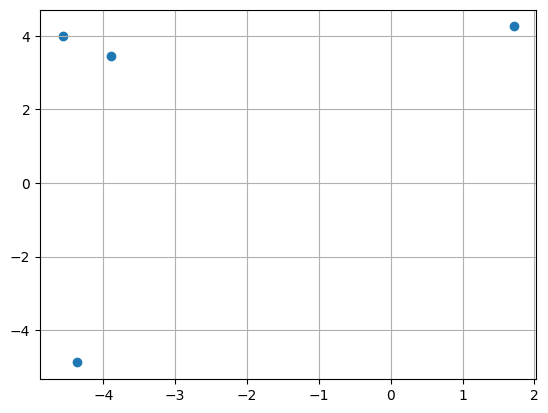

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some random points
#
std = 5
mean = 0

X = mean + np.random.uniform(-1, 1, size=(4, 2)) * std
plt.scatter(X[:,0], X[:,1])
plt.grid(True)

[-2.78015586  1.70568123]


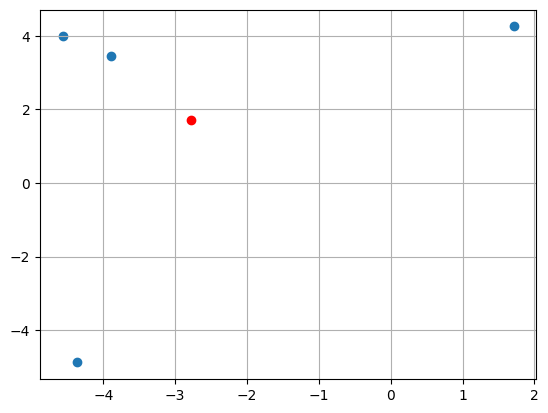

In [6]:
centroid_of_x = np.mean(X, axis=0)
print(centroid_of_x)

plt.scatter(X[:, 0], X[:, 1])
plt.scatter(centroid_of_x[0], centroid_of_x[1], color="red")
plt.grid(True)

### Exercise 2: The K-Means Algorithm


**Summary:** In this exercise you will implement the K-Means Algorithm.

**Provided Code:** The code in the cells below can be used to plot_clusters. Use the method stub defined below for your implementation.

**Your Tasks in this exercise:**
1. Implement the k-means algorithm, use X as your test data.
2. Use the ```plot_clusters()``` to visualize your results.
3. What happens when you run the clustering multiple times, how do the results change?
4. Document your learnings.


**Hints:**
* Use the ```np.random.choice()```function to select the indices to initialize the cluster centroids (use the ```replace=False``` parameter)
* You can initialize an empty numpy array using the ```np.zeros()``` function.
* The ```np.argmin()``` function can be used to find the index of the smallest value in a numpy array.
* Logical indexing can be very helpful here ```X[Y == 1, :]``` selects all vectors with a cluster label of 1.


In [7]:
# Use this function to plot your results. Notice: Only 2-dimensional features are supported.
#
def plot_clusters(X:np.array, Y):
    assert X.shape[1] == 2, 'Can only plot for 2-dimensional vectors in X'

    for k in np.unique(Y):
        plt.scatter(X[Y == k, 0], X[Y == k, 1])

In [ ]:
def kmeans(X, k):
    """ Perform k-means clustering of data X into k partitions.

    Parameters
    ----------
    X: np.array
        A numpy array of feature vectors.

    Returns
    ----------
    A one-dimensional numpy array containing the assigned cluster indices for each vector in X.
    """

    pass

In [78]:
# Use this function to plot your results. Notice: Only 2-dimensional features are supported.
#
def plot_clusters(X:np.array, Y):
    assert X.shape[1] == 2, 'Can only plot for 2-dimensional vectors in X'

    for k in np.unique(Y):
        plt.scatter(X[Y == k, 0], X[Y == k, 1])


def kmeans(X, k):
    """ Perform k-means clustering of data X into k partitions.

    Parameters
    ----------
    X: np.array
        A numpy array of feature vectors.

    Returns
    ----------
    A one-dimensional numpy array containing the assigned cluster indices for each vector in X.
    """

    n = X.shape[0]

    # Start centroids
    strc = np.random.choice(n, k, replace=False)
    centroids = X[strc, :]
    print("start centroids:")
    print(centroids)
    print()

    Y = np.zeros(n, dtype=int)

    for it in range(10):
        print(f"--- Iteration {it} ---")

        # Jeden Punkt dem nächsten centroid zuordnen
        for i in range(n):
            distances = np.linalg.norm(centroids - X[i], axis=1)
            Y[i] = np.argmin(distances)
            print(f"{X[i]} Distanzen {distances} Cluster {Y[i]}")

        print()
        print("Labels:", Y)

        # Zentroide neu berechnen
        for j in range(k):
            centroids[j] = np.mean(X[Y == j, :], axis=0)

        print()
        print("Neue centroids:")
        print(centroids)
        print()

    return Y


Y = kmeans(X, 3)


start centroids:
[[-3.89119832  3.45174807]
 [-4.3718483  -4.87522623]
 [ 1.70911912  4.25519683]]

--- Iteration 0 ---
[-4.56669592  3.99100624] Distanzen [0.86434738 8.86837324 6.28137335] Cluster 0
[-4.3718483  -4.87522623] Distanzen [ 8.34083481  0.         10.97008615] Cluster 1
[1.70911912 4.25519683] Distanzen [ 5.65765723 10.97008615  0.        ] Cluster 2
[-3.89119832  3.45174807] Distanzen [0.         8.34083481 5.65765723] Cluster 0

Labels: [0 1 2 0]

Neue centroids:
[[-4.22894712  3.72137715]
 [-4.3718483  -4.87522623]
 [ 1.70911912  4.25519683]]

--- Iteration 1 ---
[-4.56669592  3.99100624] Distanzen [0.43217369 8.86837324 6.28137335] Cluster 0
[-4.3718483  -4.87522623] Distanzen [ 8.59779103  0.         10.97008615] Cluster 1
[1.70911912 4.25519683] Distanzen [ 5.96201259 10.97008615  0.        ] Cluster 2
[-3.89119832  3.45174807] Distanzen [0.43217369 8.34083481 5.65765723] Cluster 0

Labels: [0 1 2 0]

Neue centroids:
[[-4.22894712  3.72137715]
 [-4.3718483  -4.87522

### Exercise 3: k-means in scikit-learn

**Summary:** In this task you will compare your k-means implementation with the implementation provided by scikit-learn.

**Provided Code:**  No code is provided.

**Your Tasks in this exercise:**
1. Use the scikit-learn implementation of k-means to cluster X and compare the results to your implementation.
2. What is different and why?
3. Document your learnings.


In [93]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
model.fit(X)

print("Labels:", model.labels_)
print("centroids:")
print(model.cluster_centers_)

Labels: [0 1 2 0]
centroids:
[[-4.22894712  3.72137715]
 [-4.3718483  -4.87522623]
 [ 1.70911912  4.25519683]]


### Exercise 4: Silhouette

**Summary:** In this exercise you will use the silhouette score to determine heuristically a good number of clusters   
to use. To do so, perform kmeans clustering (use either scikit-learn if you could not implement it or your own implementation)   
within an interval of clusters $[2;k]$ and compute the silhouette score for your result. The key idea: A high silhouette score   
most likely indicates a good number of clusters.

**Provided Code:** The cell below can be used to generate data from k distinct clusters. Use ```random_labels=True``` to generate   
random labels (i.e.: no internal structure).

**Your Tasks in this exercise:**
1. Use the ```silhouette_score()``` function in scikit-learn to determine the best number of clusters.
2. Interpret and plot the results.
3. Compare the silhouette score of clustering random points (use ```random_labels=True```  parameter) to a clustering of points with meaningful labels.  
3. Document your learnings.

In [94]:
# Generate data from k distinct clusters
#
def gen_data(k = 2, random_labels = False):
    X = []
    Y = []

    for i in range(k):
        std = np.random.randn()
        mean = np.random.randn() + i

        tmp = mean + np.random.uniform(-1, 1, size=(50, 2)) * std
        X.append(tmp)
        Y.append(np.ones(50) * i)

    Y = np.array(Y).ravel()
    if random_labels:
        np.random.shuffle(Y)

    return np.array(X).reshape(k * 50, 2), Y

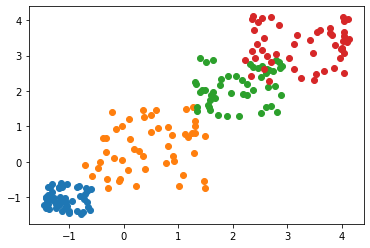

In [ ]:
n_clusters = 4
X2, Y2 = gen_data(n_clusters)
plot_clusters(X2, Y2)

k = 2: Score = 0.838
k = 3: Score = 0.722
k = 4: Score = 0.710
k = 5: Score = 0.484
k = 6: Score = 0.469
k = 7: Score = 0.478
k = 8: Score = 0.480
k = 9: Score = 0.492
k = 10: Score = 0.501


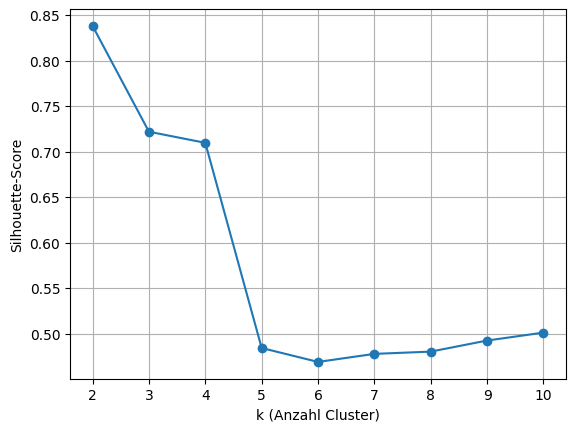

In [97]:
from sklearn.metrics import silhouette_score

X, Y_true = gen_data(k=4)

ks = range(2, 11)   # k = 2 bis 10
scores = []

for k in ks:
    model = KMeans(n_clusters=k)
    model.fit(X)

    score = silhouette_score(X, model.labels_)
    scores.append(score)
    print(f"k = {k}: Score = {score:.3f}")


plt.plot(ks, scores, marker="o")
plt.xlabel("k (Anzahl Cluster)")
plt.ylabel("Silhouette-Score")
plt.grid(True)
plt.show()